# Zomato Restaurant Analysis for Alfido Tech

## Project Objective

The objective of this project is to analyze Zomato restaurant data and identify insights related to customer preferences, restaurant ratings, cuisine popularity, restaurant hotspots, pricing patterns, and factors affecting ratings. The findings will help provide business recommendations for an Alfido Tech style restaurant discovery platform.

In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import warnings
warnings.filterwarnings('ignore')

## Dataset Loading

The dataset is loaded into a Pandas DataFrame for further analysis.

In [39]:
df = pd.read_csv("zomato.csv")

df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


## Dataset Overview

Understanding the structure of the dataset including number of rows, columns and data types.

In [40]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape:
(56252, 13)

Column Names:
['address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'listed_in(type)']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked        

In [41]:
df.isnull().sum()

,0
address,17
name,16
online_order,19
book_table,58
rate,7838
votes,78
phone,1296
location,126
rest_type,338
dish_liked,28225


## Data Cleaning

The dataset contains missing values and corrupted records. Data cleaning is performed to ensure accurate analysis.

Cleaning steps:

1. Remove duplicate records.
2. Handle missing values.
3. Remove invalid rating entries.
4. Convert rating column to numeric format.
5. Convert votes column to numeric format.
6. Convert cost column to numeric format.
7. Remove unnecessary information.

In [42]:
df = df.drop_duplicates()

df = df.dropna(subset=['rate'])

df['location'] = df['location'].fillna('Unknown')
df['rest_type'] = df['rest_type'].fillna('Unknown')
df['cuisines'] = df['cuisines'].fillna('Unknown')
df['dish_liked'] = df['dish_liked'].fillna('Not Mentioned')
df['online_order'] = df['online_order'].fillna('No')
df['book_table'] = df['book_table'].fillna('No')
df['listed_in(type)'] = df['listed_in(type)'].fillna('Others')

df['votes'] = pd.to_numeric(df['votes'], errors='coerce')
df['votes'] = df['votes'].fillna(df['votes'].median())

df['address'] = df['address'].fillna('Unknown')

In [43]:
df = df[
    df['rate'].astype(str)
    .str.contains(r'^\d\.\d/5$', regex=True)
]

df['rate'] = df['rate'].str.replace('/5', '', regex=False)

df['rate'] = pd.to_numeric(
    df['rate'],
    errors='coerce'
)

In [44]:
df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '')
)

df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'],
    errors='coerce'
)

df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .fillna(
        df['approx_cost(for two people)'].median()
    )
)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15897 entries, 0 to 30209
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   address                      15897 non-null  object 
 1   name                         15897 non-null  object 
 2   online_order                 15897 non-null  object 
 3   book_table                   15897 non-null  object 
 4   rate                         15897 non-null  float64
 5   votes                        15897 non-null  float64
 6   phone                        15647 non-null  object 
 7   location                     15897 non-null  object 
 8   rest_type                    15897 non-null  object 
 9   dish_liked                   15897 non-null  object 
 10  cuisines                     15897 non-null  object 
 11  approx_cost(for two people)  15897 non-null  float64
 12  listed_in(type)              15897 non-null  object 
dtypes: float64(3), object

In [46]:
df.isnull().sum()

,0
address,0
name,0
online_order,0
book_table,0
rate,0
votes,0
phone,250
location,0
rest_type,0
dish_liked,0


In [47]:
df.to_csv("cleaned_zomato.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# Exploratory Data Analysis

The following visualizations help understand cuisine popularity, location trends, customer preferences, and factors affecting restaurant ratings.

## Top 10 Most Popular Cuisines

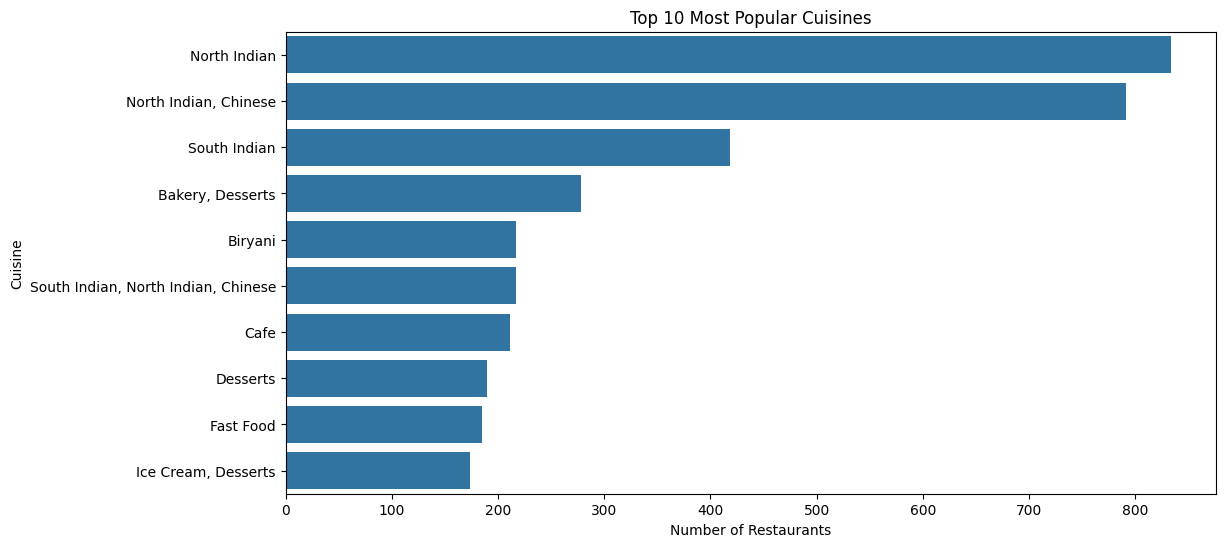

In [48]:
top_cuisines = df['cuisines'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_cuisines.values,
    y=top_cuisines.index
)

plt.title("Top 10 Most Popular Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")

plt.show()

Interpretation:

North Indian cuisine dominates the restaurant market followed by North Indian-Chinese combinations and South Indian cuisine.

## Highest Rated Cuisines

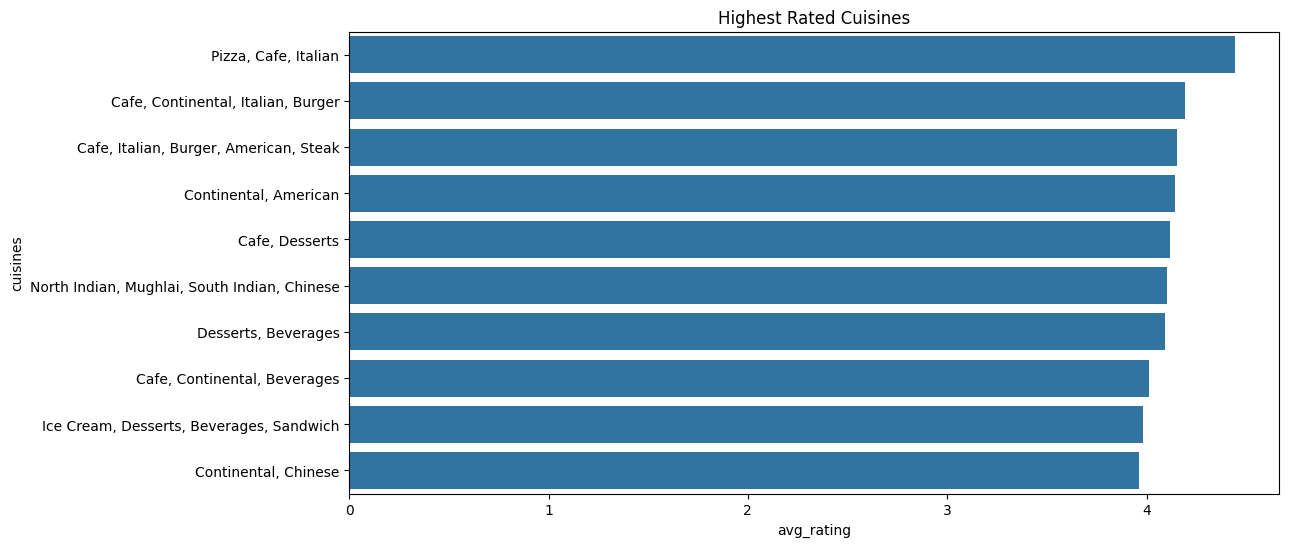

In [49]:
cuisine_stats = (
    df.groupby('cuisines')
      .agg({'rate':['mean','count']})
)

cuisine_stats.columns = ['avg_rating','count']

cuisine_stats = cuisine_stats[
    cuisine_stats['count'] >= 20
]

top_rated = cuisine_stats.sort_values(
    'avg_rating',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_rated['avg_rating'],
    y=top_rated.index
)

plt.title("Highest Rated Cuisines")

plt.show()

Interpretation:

Fusion cuisines and premium dining combinations receive the highest customer ratings.

## Restaurant Hotspots

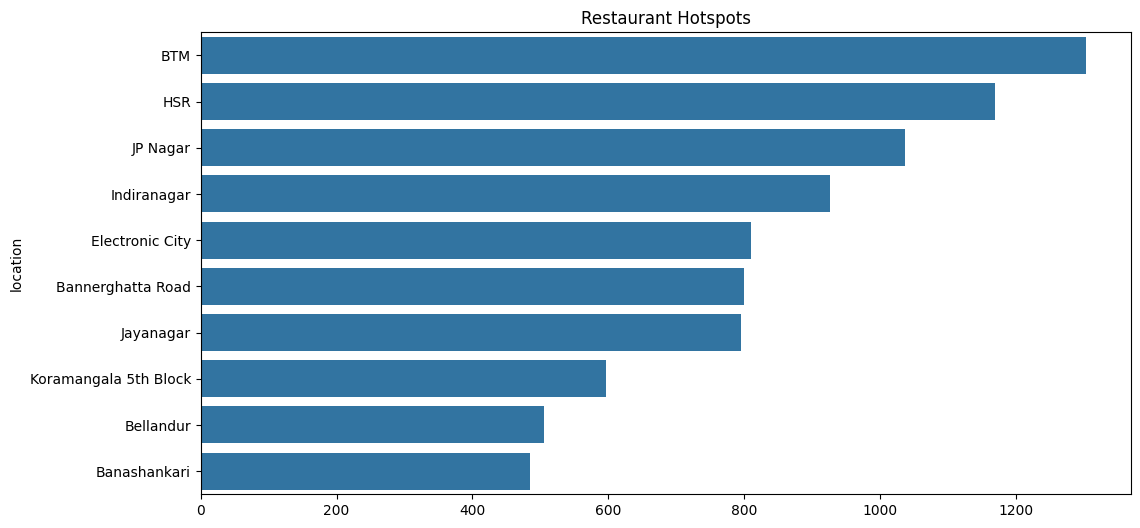

In [50]:
top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_locations.values,
    y=top_locations.index
)

plt.title("Restaurant Hotspots")

plt.show()

Interpretation:

BTM, HSR and JP Nagar are major restaurant hubs with the highest concentration of restaurants.

## Highest Rated Locations

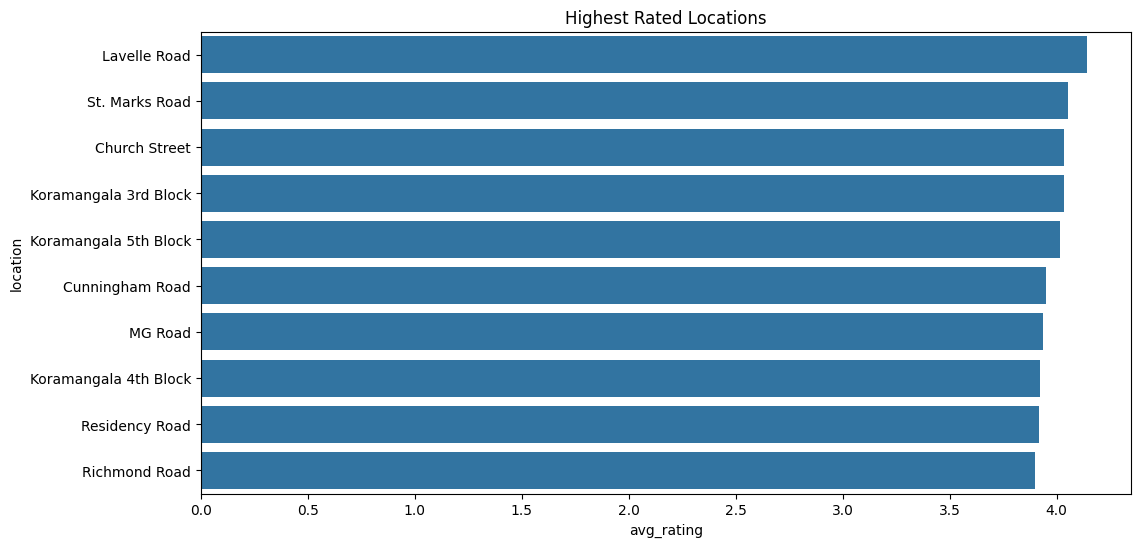

In [51]:
location_stats = (
    df.groupby('location')
      .agg({'rate':['mean','count']})
)

location_stats.columns = ['avg_rating','count']

location_stats = location_stats[
    location_stats['count'] >= 20
]

best_locations = location_stats.sort_values(
    'avg_rating',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=best_locations['avg_rating'],
    y=best_locations.index
)

plt.title("Highest Rated Locations")

plt.show()

Interpretation:

Lavelle Road, Church Street and St. Marks Road contain the highest-rated restaurants.


## Price vs Rating Analysis

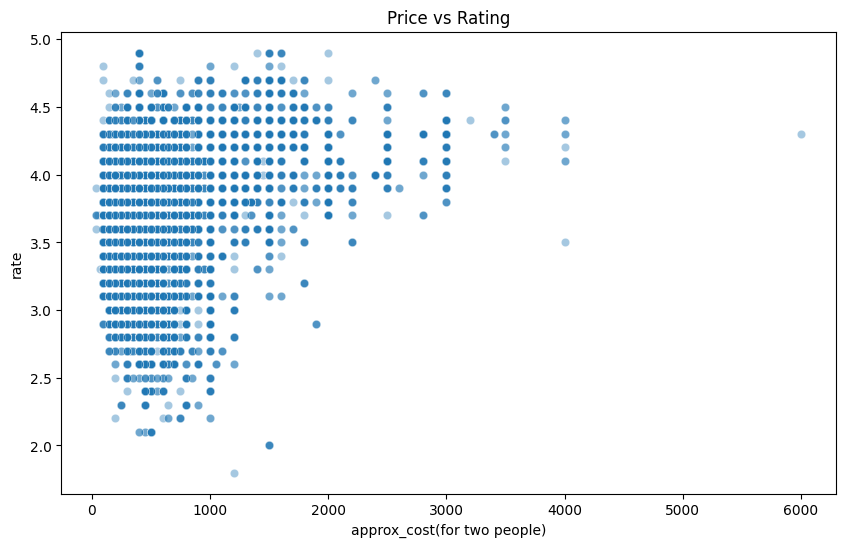

In [52]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='approx_cost(for two people)',
    y='rate',
    alpha=0.4
)

plt.title("Price vs Rating")

plt.show()

Interpretation:

Higher prices do not necessarily result in higher ratings. Affordable restaurants can achieve ratings comparable to premium restaurants.

## Correlation Heatmap

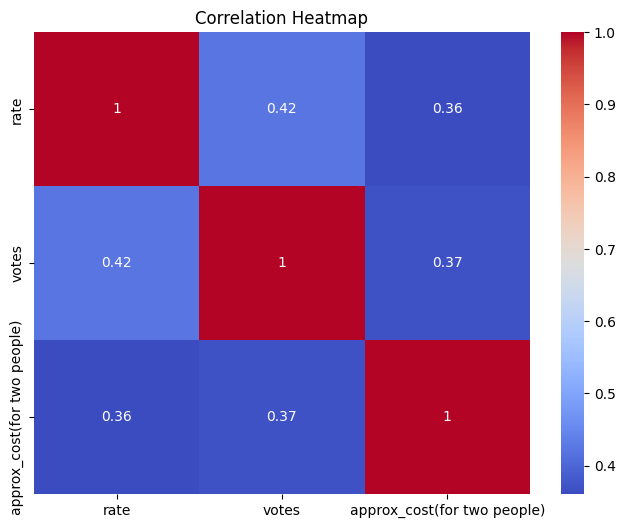

In [53]:
numeric_df = df[
    ['rate','votes','approx_cost(for two people)']
]

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

Interpretation:

Ratings show a stronger relationship with customer engagement (votes) than with restaurant pricing.

## Cuisine Word Cloud

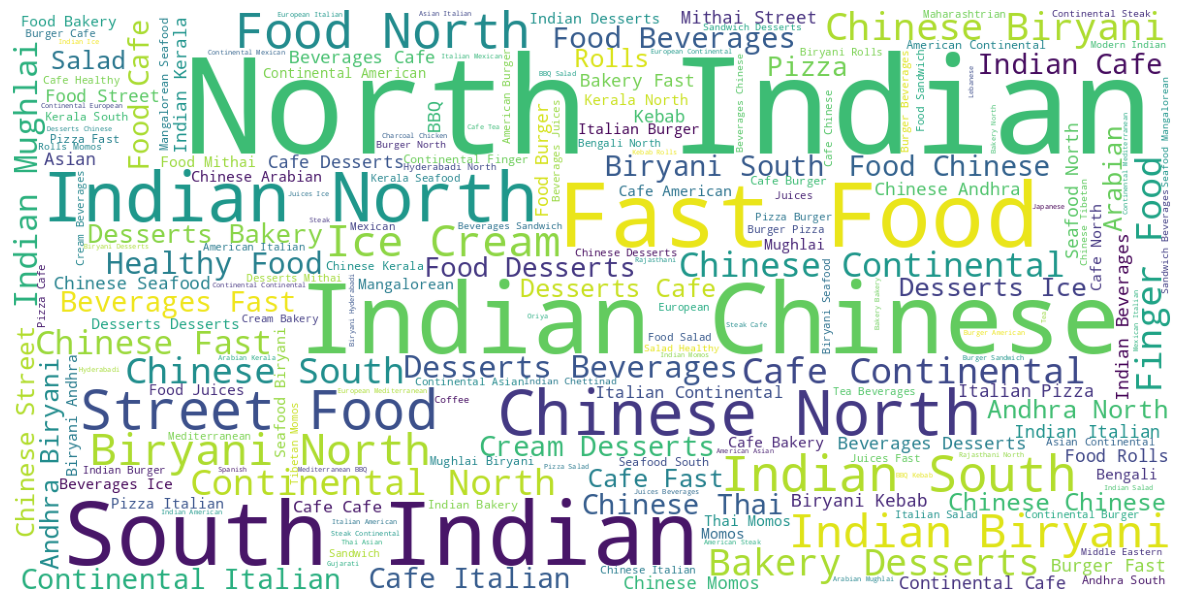

In [54]:
text = " ".join(
    df['cuisines'].astype(str)
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

Interpretation:

North Indian, Chinese, South Indian, Fast Food and Biryani dominate restaurant offerings.

## Online Order vs Rating

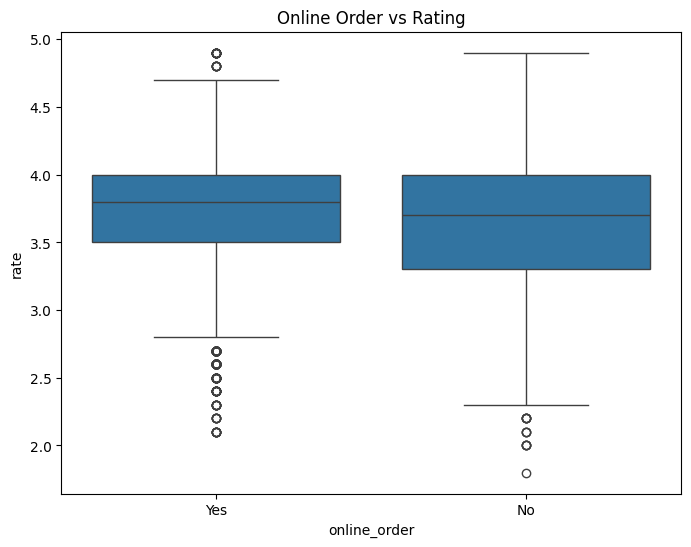

In [55]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='online_order',
    y='rate',
    data=df
)

plt.title("Online Order vs Rating")

plt.show()

Interpretation:

Restaurants offering online ordering generally receive slightly better ratings.

## Table Booking vs Rating

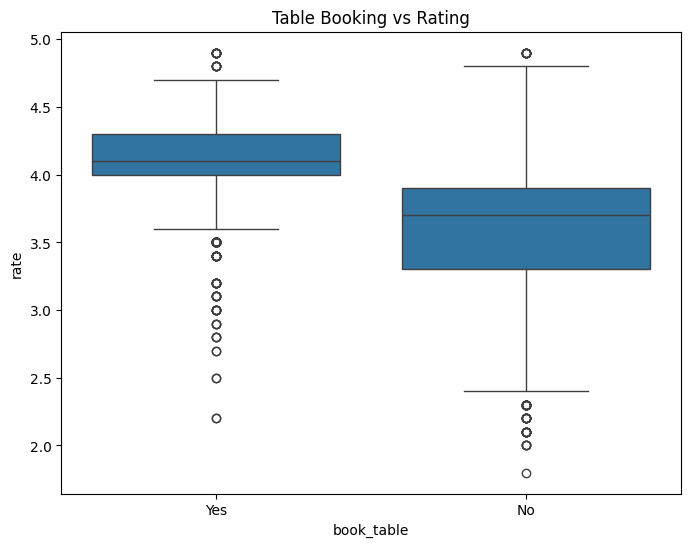

In [56]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='book_table',
    y='rate',
    data=df
)

plt.title("Table Booking vs Rating")

plt.show()

Interpretation:

Restaurants with table-booking facilities tend to achieve higher customer ratings.

# Key Findings

1. North Indian cuisine is the most popular cuisine category.
2. Chinese and South Indian cuisines are also highly demanded.
3. Fusion cuisines receive the highest average ratings.
4. BTM and HSR are major restaurant hotspots.
5. Premium locations such as Lavelle Road and Church Street achieve the highest ratings.
6. Restaurant ratings are moderately correlated with customer votes.
7. Price has only a weak-to-moderate influence on ratings.
8. Online ordering improves customer satisfaction.
9. Table booking facilities are associated with better ratings.

# Recommendations for Alfido Tech

1. Partner with highly rated restaurants for premium visibility.
2. Promote trending cuisines such as North Indian, Chinese, Biryani and South Indian food.
3. Implement location-based recommendation systems.
4. Encourage customers to leave reviews through loyalty rewards and incentives.
5. Highlight restaurants offering online ordering and table-booking facilities.

# Conclusion

The project successfully analyzed restaurant trends using the Zomato dataset. Cuisine preferences, restaurant hotspots, pricing patterns and service features were studied to understand customer behavior. The insights obtained can help Alfido Tech improve recommendation systems, partnership strategies and customer engagement initiatives.